In [33]:
#!/usr/bin/env python3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas_profiling as pp

golf_scores = pd.read_csv('golf_scores.csv')
golf_scores['Date'] = pd.to_datetime(golf_scores['Date'])
golf_scores.head()

,Date,Course,Player,h1,h2,h3,h4,h5,h6,h7,...,h13,h14,h15,h16,h17,h18,f9,b9,total,Round
0,2012-01-07,Rose City,Jason,4,5,6,5,3,5,6,...,7,4,4,7,6,5,45,49,94,NaN
1,2012-01-07,Rose City,Bobby,6,6,7,4,5,8,9,...,7,6,4,8,8,8,56,63,119,NaN
2,2012-01-07,Rose City,Leif,6,5,7,6,4,6,8,...,5,5,5,7,7,9,49,59,108,NaN
3,2012-01-28,Red Tail,Jason,5,4,6,5,5,4,8,...,7,5,6,4,5,8,49,51,100,NaN
4,2012-01-28,Red Tail,Bobby,7,4,8,9,6,7,7,...,7,8,7,5,7,7,62,58,120,NaN


In [5]:
golf_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    135 non-null    datetime64[ns]
 1   Course  135 non-null    object        
 2   Player  135 non-null    object        
 3   h1      135 non-null    int64         
 4   h2      135 non-null    int64         
 5   h3      135 non-null    int64         
 6   h4      135 non-null    int64         
 7   h5      135 non-null    int64         
 8   h6      135 non-null    int64         
 9   h7      135 non-null    int64         
 10  h8      135 non-null    int64         
 11  h9      135 non-null    int64         
 12  h10     135 non-null    int64         
 13  h11     135 non-null    int64         
 14  h12     135 non-null    int64         
 15  h13     135 non-null    int64         
 16  h14     135 non-null    int64         
 17  h15     135 non-null    int64         
 18  h16     13

In [7]:
missing_percentage = golf_scores.isnull().sum() * 100 / len(golf_scores)

In [9]:
golf_scores['year'] = golf_scores['Date'].dt.year

In [10]:
by_year = golf_scores['total'].groupby(golf_scores['year'])

In [11]:
by_year.describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2012,30.0,103.933333,9.431910,87.0,97.25,102.5,110.50,121.0
2018,34.0,88.205882,5.628819,78.0,84.25,88.0,91.75,99.0
2020,24.0,85.125000,5.697540,74.0,81.75,85.5,88.25,98.0
2021,47.0,87.319149,6.122327,76.0,82.50,88.0,92.00,99.0


In [12]:
by_year.mean()

year
2012    103.933333
2018     88.205882
2020     85.125000
2021     87.319149
Name: total, dtype: float64

In [14]:
data = by_year.mean()

<AxesSubplot:title={'center':'scores'}, xlabel='year'>

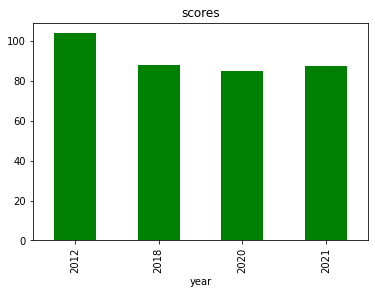

In [23]:
data.plot.bar(color = 'g', title = 'scores')

(array([ 7., 25., 31., 24., 22., 11.,  3.,  5.,  3.,  4.]),
 array([ 74. ,  78.7,  83.4,  88.1,  92.8,  97.5, 102.2, 106.9, 111.6,
        116.3, 121. ]),
 <BarContainer object of 10 artists>)

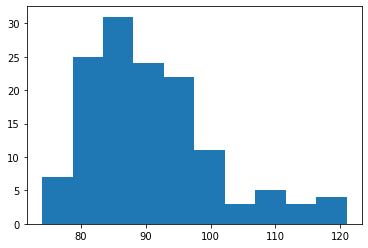

In [24]:
plt.hist(golf_scores['total'])

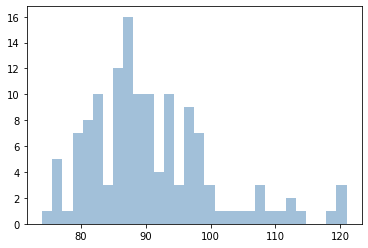

In [26]:
plt.hist(golf_scores['total'], bins=30, alpha=0.5,
         histtype='stepfilled', color='steelblue',
         edgecolor='none');

In [28]:
plt.style.available[:5]

['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background']

In [29]:
def hist_and_lines():
    np.random.seed(0)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].hist(np.random.randn(1000))
    for i in range(3):
        ax[1].plot(np.random.rand(10))
    ax[1].legend(['a', 'b', 'c'], loc='lower left')

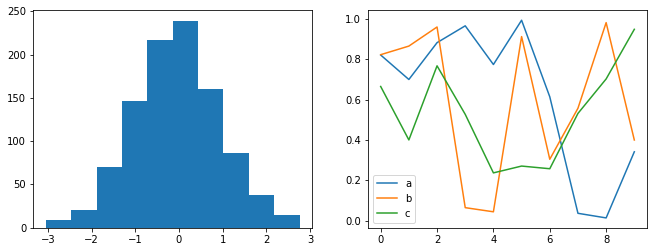

In [30]:
hist_and_lines()

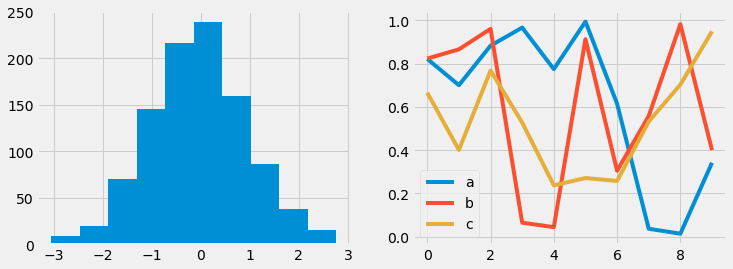

In [31]:
with plt.style.context('fivethirtyeight'):
    hist_and_lines()

In [32]:
pp.ProfileReport(golf_scores)

NameError: name 'pp' is not defined

In [16]:
courses = golf_scores['total'].groupby(golf_scores['Course'])
courses.describe()

,count,mean,std,min,25%,50%,75%,max
Course,,,,,,,,
Elk Ridge,4.0,87.250000,3.774917,82.0,86.50,88.0,88.75,91.0
Heron Lakes Great Blue,3.0,91.666667,4.618802,89.0,89.00,89.0,93.00,97.0
Heron Lakes Greenback,58.0,87.068966,6.040396,74.0,82.25,86.5,91.00,99.0
Oregon City Golf Club,8.0,97.125000,5.540436,87.0,95.25,98.0,99.25,106.0
Red Tail,8.0,109.000000,10.267842,90.0,106.00,109.5,115.50,121.0
Rose City,11.0,104.727273,9.727188,92.0,96.50,103.0,110.50,120.0
Stone Creek,4.0,87.250000,8.180261,77.0,84.50,87.5,90.25,97.0
Tri Mountain,3.0,105.666667,6.658328,100.0,102.00,104.0,108.50,113.0
Wildwood,36.0,86.750000,5.905808,76.0,82.50,88.0,91.00,98.0


In [18]:
players = golf_scores['total'].groupby(golf_scores['Player'])
players.describe()

,count,mean,std,min,25%,50%,75%,max
Player,,,,,,,,
Bobby,31.0,88.612903,12.978643,76.0,79.0,84.0,97.50,120.0
Fuj,32.0,94.437500,9.249019,81.0,88.0,92.5,97.25,121.0
Jason,39.0,87.179487,5.897688,74.0,83.0,87.0,91.00,100.0
Leif,8.0,106.750000,5.035588,96.0,105.5,108.0,109.50,112.0
Matt,25.0,89.640000,4.498889,81.0,87.0,89.0,94.00,97.0


In [20]:
means = golf_scores['total'].groupby([golf_scores['Player'], golf_scores['Course']]).mean()
means

Player  Course                
Bobby   Elk Ridge                  82.000000
        Heron Lakes Greenback      83.500000
        Oregon City Golf Club      98.000000
        Red Tail                  114.000000
        Rose City                 108.000000
        Stone Creek                77.000000
        Tri Mountain              113.000000
        Wildwood                   79.714286
Fuj     Elk Ridge                  88.000000
        Heron Lakes Great Blue     97.000000
        Heron Lakes Greenback      91.125000
        Oregon City Golf Club      99.500000
        Red Tail                  117.500000
        Rose City                 120.000000
        Stone Creek                97.000000
        Wildwood                   91.000000
Jason   Elk Ridge                  88.000000
        Heron Lakes Great Blue     89.000000
        Heron Lakes Greenback      85.250000
        Oregon City Golf Club      90.000000
        Red Tail                   95.000000
        Rose City       

In [21]:
counts = golf_scores['total'].groupby([golf_scores['Player'], golf_scores['Course']]).count()
counts

Player  Course                
Bobby   Elk Ridge                  1
        Heron Lakes Greenback     14
        Oregon City Golf Club      2
        Red Tail                   2
        Rose City                  3
        Stone Creek                1
        Tri Mountain               1
        Wildwood                   7
Fuj     Elk Ridge                  1
        Heron Lakes Great Blue     1
        Heron Lakes Greenback     16
        Oregon City Golf Club      2
        Red Tail                   2
        Rose City                  1
        Stone Creek                1
        Wildwood                   8
Jason   Elk Ridge                  1
        Heron Lakes Great Blue     1
        Heron Lakes Greenback     16
        Oregon City Golf Club      2
        Red Tail                   2
        Rose City                  4
        Stone Creek                1
        Tri Mountain               1
        Wildwood                  11
Leif    Oregon City Golf Club      2
       